In [1]:
import torch
import torchvision.models as models
from torchvision.models import ResNet50_Weights

from brise.rise import RISE
from brise.brise import B_RISE
from brise.evaluation import evaluate_saliency, blur_substrate, zero_substrate

import brise.utils as utils
from brise.utils import IMAGES

## Model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained weights
weights = ResNet50_Weights.DEFAULT

# Build model
model = models.resnet50(weights=weights)
model = model.to(device)
model.eval()

# Preprocessing transform
preprocess = weights.transforms()

## Init RISE

In [3]:
img_path = IMAGES / "catdog.png"
img, img_x = utils.load_image(img_path, device, preprocess)

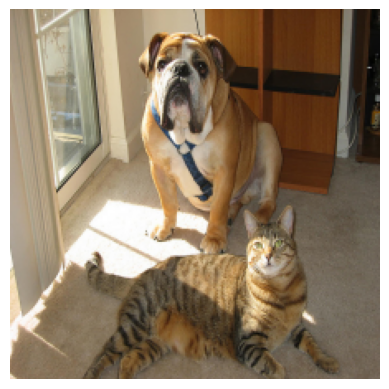

In [4]:
utils.draw_image(img)

In [5]:
rise = RISE(model, img_x)
rise.generate_masks(N=5000, s=7, p=0.1)

Generating filters: 100%|██████████| 5000/5000 [00:01<00:00, 3240.87it/s]


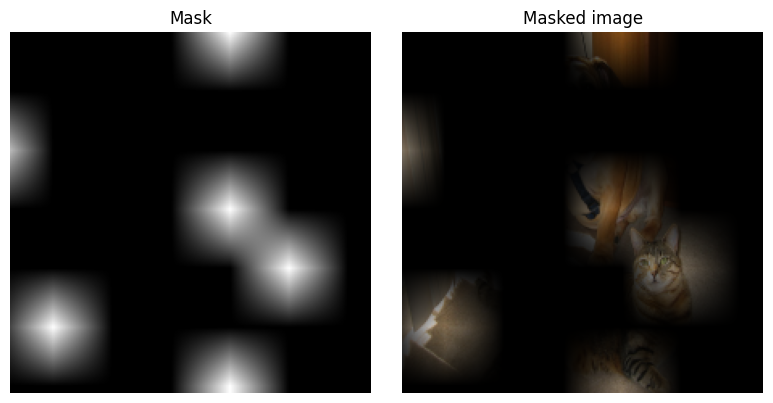

In [6]:
utils.draw_masked_image(img, rise.masks[42])

## RISE

In [7]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)
topk

[{'class_id': 243, 'class_name': 'bull mastiff', 'logit': 6.158624649047852},
 {'class_id': 281, 'class_name': 'tabby', 'logit': 3.580155372619629},
 {'class_id': 242, 'class_name': 'boxer', 'logit': 3.4773547649383545},
 {'class_id': 180,
  'class_name': 'American Staffordshire terrier',
  'logit': 3.336127996444702},
 {'class_id': 282, 'class_name': 'tiger cat', 'logit': 3.32332181930542}]

In [8]:
sal = rise(img_x)

Running model: 100%|██████████| 50/50 [00:05<00:00,  8.50it/s]


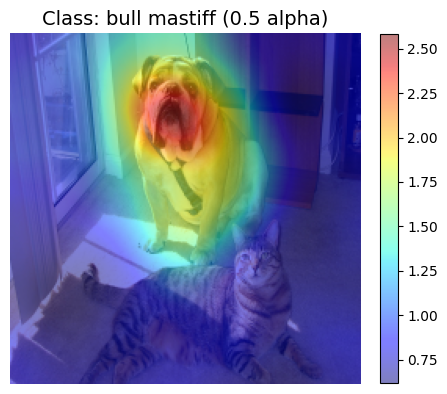

In [9]:
sal_map1 = utils.draw_saliency_overlay(img, sal, topk, k=0, norm_mode="minmax", alpha=0.5, cmap="jet")

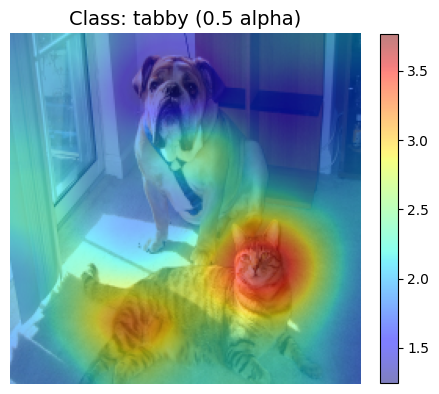

In [10]:
sal_map2 = utils.draw_saliency_overlay(img, sal, topk, k=1, norm_mode="minmax", alpha=0.5, cmap="jet")


### Evaluate

In [11]:
scores_del, auc_del = evaluate_saliency(
    model,
    img_x,
    sal_map1,
    mode="del",
    target_class=topk[0]["class_id"],
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.013057765189838406


In [12]:
scores_ins, auc_ins = evaluate_saliency(
    model,
    img_x,
    sal_map1,
    mode="ins",
    target_class=topk[0]["class_id"],
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.36756632969259245


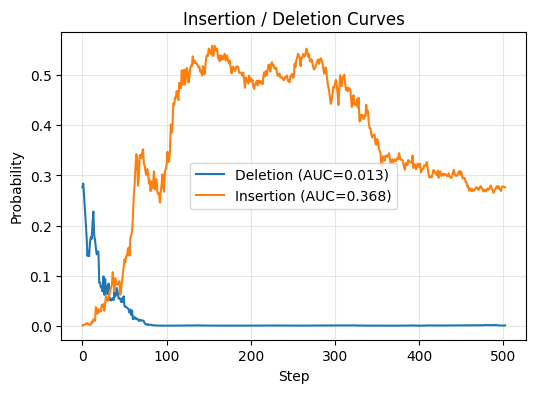

In [13]:
utils.plot_ins_del(scores_ins, auc_ins, scores_del, auc_del)

# Banzhaf RISE

In [14]:
brise = B_RISE(model, img_x)

In [15]:
brise.generate_masks(500, 9, 0.5)

In [16]:
sal_brise = brise.forward(img_x, K=5)

Estimated forward passes: 3000


Banzhaf sampling: 100%|██████████| 500/500 [00:16<00:00, 30.27it/s]

Total forward passes: 3000


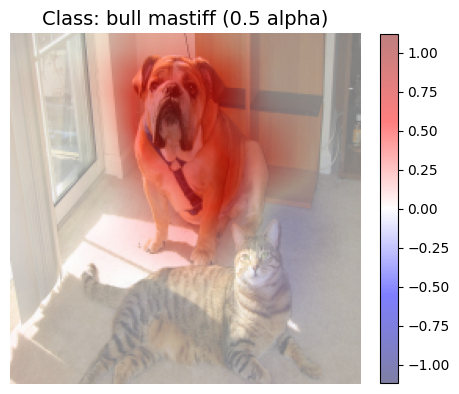

In [17]:
sal_map_brise = utils.draw_saliency_overlay(img, sal_brise, topk, k=0, norm_mode="symmetric", alpha=0.5, cmap="seismic")

### Evaluate

In [18]:
scores_del, auc_del = evaluate_saliency(
    model,
    img_x,
    sal_map_brise,
    mode="del",
    target_class=topk[0]["class_id"],
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.01401375646160756


In [19]:
scores_ins, auc_ins = evaluate_saliency(
    model,
    img_x,
    sal_map_brise,
    mode="ins",
    target_class=topk[0]["class_id"],
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.38977129818557155


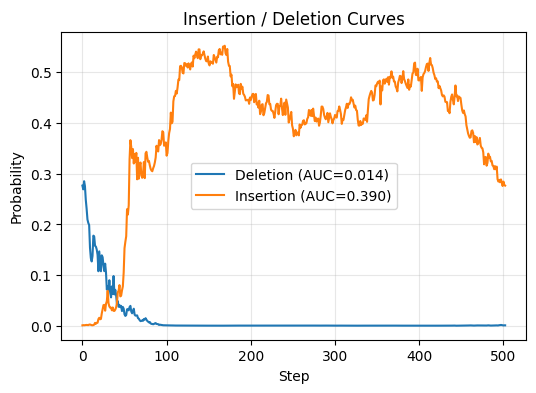

In [20]:
utils.plot_ins_del(scores_ins, auc_ins, scores_del, auc_del)

## Another Image

In [21]:
img_path = IMAGES / "prens.png"
img, img_x = utils.load_image(img_path, device, preprocess)

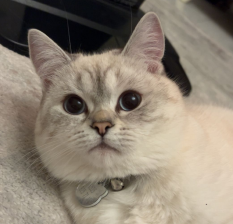

In [22]:
img

In [23]:
rise = RISE(model, img_x)
rise.generate_masks(N=4000, s=7, p=0.1)

Generating filters: 100%|██████████| 4000/4000 [00:01<00:00, 2890.53it/s]


In [24]:
sal = rise.forward(img_x)

Running model: 100%|██████████| 40/40 [00:04<00:00,  8.56it/s]


In [25]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)

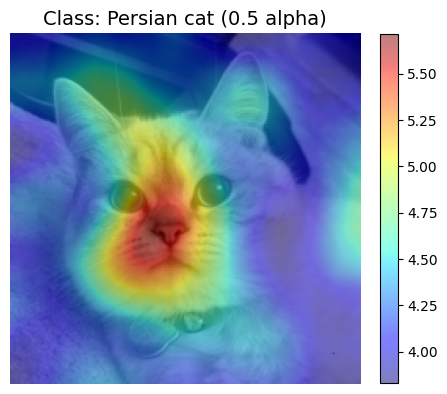

In [26]:
sal_map = utils.draw_saliency_overlay(img, sal, topk=topk, k=1, norm_mode="minmax", alpha=0.5, cmap="jet")

In [27]:
brise = B_RISE(model, img_x)
brise.generate_masks(1000, 9, 0.5)
sal_brise = brise.forward(img_x, K=5)

Estimated forward passes: 6000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:32<00:00, 31.05it/s]

Total forward passes: 6000


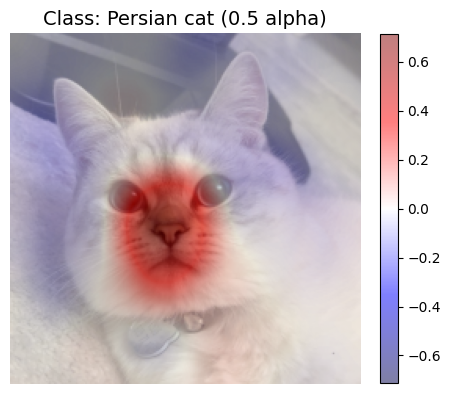

In [28]:
sal_map_brise = utils.draw_saliency_overlay(img, sal_brise, topk, k=1, norm_mode="symmetric", alpha=0.5, cmap="seismic")

## Another Image

In [29]:
img_path = IMAGES / "goldfish.jpg"
img, img_x = utils.load_image(img_path, device, preprocess)

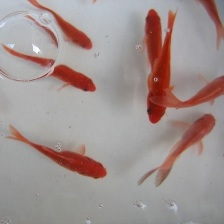

In [30]:
img

### RISE

In [44]:
rise = RISE(model, img_x)
rise.generate_masks(N=10000, s=9, p=0.1)

Generating filters: 100%|██████████| 10000/10000 [00:03<00:00, 2835.83it/s]


In [45]:
sal = rise.forward(img_x)

Running model: 100%|██████████| 100/100 [00:13<00:00,  7.32it/s]


In [46]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)

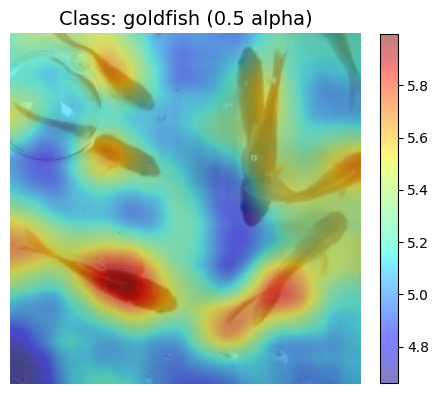

In [47]:
sal_map = utils.draw_saliency_overlay(img, sal, topk=topk, k=0, norm_mode="minmax", alpha=0.5, cmap="jet")

#### Evaluate

In [48]:
scores_del, auc_del = evaluate_saliency(
    model,
    img_x,
    sal_map,
    mode="del",
    target_class=topk[0]["class_id"],
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.20230105918539


In [49]:
scores_ins, auc_ins = evaluate_saliency(
    model,
    img_x,
    sal_map,
    mode="ins",
    target_class=topk[0]["class_id"],
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.333450743906289


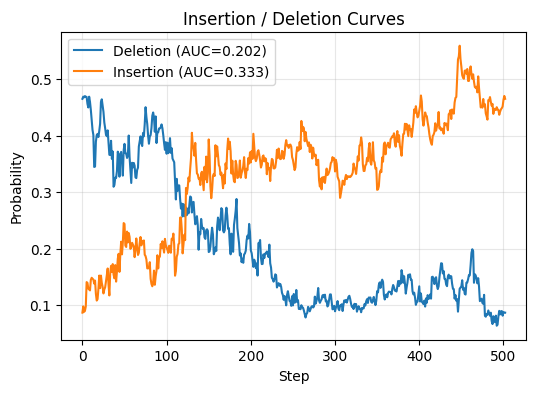

In [50]:
utils.plot_ins_del(scores_ins, auc_ins, scores_del, auc_del)

### BRISE

In [38]:
brise = B_RISE(model, img_x)
brise.generate_masks(2000, 10, 0.1)
sal_brise = brise.forward(img_x, K=5)

Estimated forward passes: 12000


Banzhaf sampling:   0%|          | 0/2000 [00:00<?, ?it/s]

Banzhaf sampling: 100%|██████████| 2000/2000 [01:03<00:00, 31.26it/s]

Total forward passes: 12000


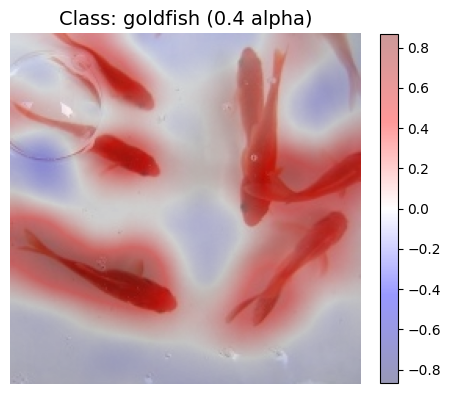

In [39]:
sal_map_brise = utils.draw_saliency_overlay(img, sal_brise, topk, k=0, norm_mode="symmetric", alpha=0.4, cmap="seismic")

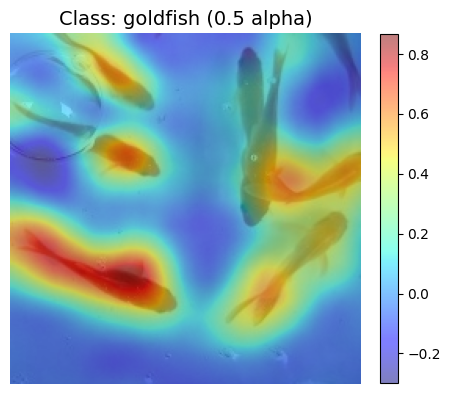

In [56]:
sal_map_brise = utils.draw_saliency_overlay(img, sal_brise, topk, k=0, norm_mode="minmax", alpha=0.5, cmap="jet")

#### Evaluate

In [40]:
scores_del, auc_del = evaluate_saliency(
    model,
    img_x,
    sal_map_brise,
    mode="del",
    target_class=topk[0]["class_id"],
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.16802692549132495


In [41]:
scores_ins, auc_ins = evaluate_saliency(
    model,
    img_x,
    sal_map_brise,
    mode="ins",
    target_class=topk[0]["class_id"],
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.381818693160892


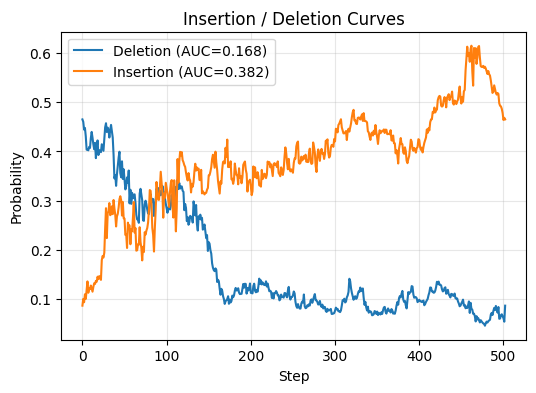

In [42]:
utils.plot_ins_del(scores_ins, auc_ins, scores_del, auc_del)